In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr

import os

os.makedirs('slike_redukcija', exist_ok=True)

print("Biblioteke uspešno učitane.")

Biblioteke uspešno učitane.


In [38]:
merged = pd.read_csv('merged_dataset.csv')

print("Dimenzije skupa:", merged.shape)
display(merged.head())

Dimenzije skupa: (873, 35)


,O*NET-SOC Code,Title,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma,Job Zone,Active_Learning_Importance,...,Science_Importance,Science_Level,Speaking_Importance,Speaking_Level,Writing_Importance,Writing_Level,degree_of_automation_context,importance_of_being_exact_or_accurate_context,importance_of_repeating_same_tasks_context,structured_versus_unstructured_work_context
0,11-1011.00,Chief Executives,0.100000,0.460000,0.820000,0.180000,0.350000,0.520000,5,75,...,22,16.0,85,70,75,63,0.42,0.79,0.56,1.00
1,11-1011.03,Chief Sustainability Officers,0.166667,0.555556,0.944444,0.055556,0.388889,0.722222,5,69,...,28,27.0,75,59,78,61,0.14,0.63,0.20,0.86
2,11-1021.00,General and Operations Managers,0.000000,0.480769,0.961538,0.115385,0.384615,0.653846,4,63,...,22,16.0,75,57,56,55,0.32,0.75,0.65,0.95
3,11-2011.00,Advertising and Promotions Managers,0.000000,0.476744,0.953488,0.255814,0.546512,0.837209,4,56,...,16,9.0,75,59,69,55,0.25,0.83,0.43,0.81
4,11-2021.00,Marketing Managers,0.062500,0.500000,0.937500,0.218750,0.578125,0.937500,4,72,...,19,21.0,72,59,56,55,0.28,0.70,0.45,0.91


In [39]:
TARGET = 'human_rating_beta'

leak_cols = [
    'O*NET-SOC Code',
    'Title',
    'dv_rating_alpha',
    'dv_rating_beta',
    'dv_rating_gamma',
    'human_rating_alpha',
    'human_rating_gamma',
    'human_rating_beta'
]

X = merged.drop(columns=leak_cols)
y = merged[TARGET]

print("Broj zanimanja:", X.shape[0])
print("Broj prediktora:", X.shape[1])

print("\nPrediktori:")
for col in X.columns:
    print(col)

Broj zanimanja: 873
Broj prediktora: 27

Prediktori:
Job Zone
Active_Learning_Importance
Active_Learning_Level
Critical_Thinking_Importance
Critical_Thinking_Level
Learning_Strategies_Importance
Learning_Strategies_Level
Monitoring_Importance
Monitoring_Level
Active_Listening_Importance
Active_Listening_Level
Mathematics_Importance
Mathematics_Level
Programming_Importance
Programming_Level
Reading_Comprehension_Importance
Reading_Comprehension_Level
Science_Importance
Science_Level
Speaking_Importance
Speaking_Level
Writing_Importance
Writing_Level
degree_of_automation_context
importance_of_being_exact_or_accurate_context
importance_of_repeating_same_tasks_context
structured_versus_unstructured_work_context


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Trening skup:", X_train.shape)
print("Test skup:", X_test.shape)

Trening skup: (698, 27)
Test skup: (175, 27)


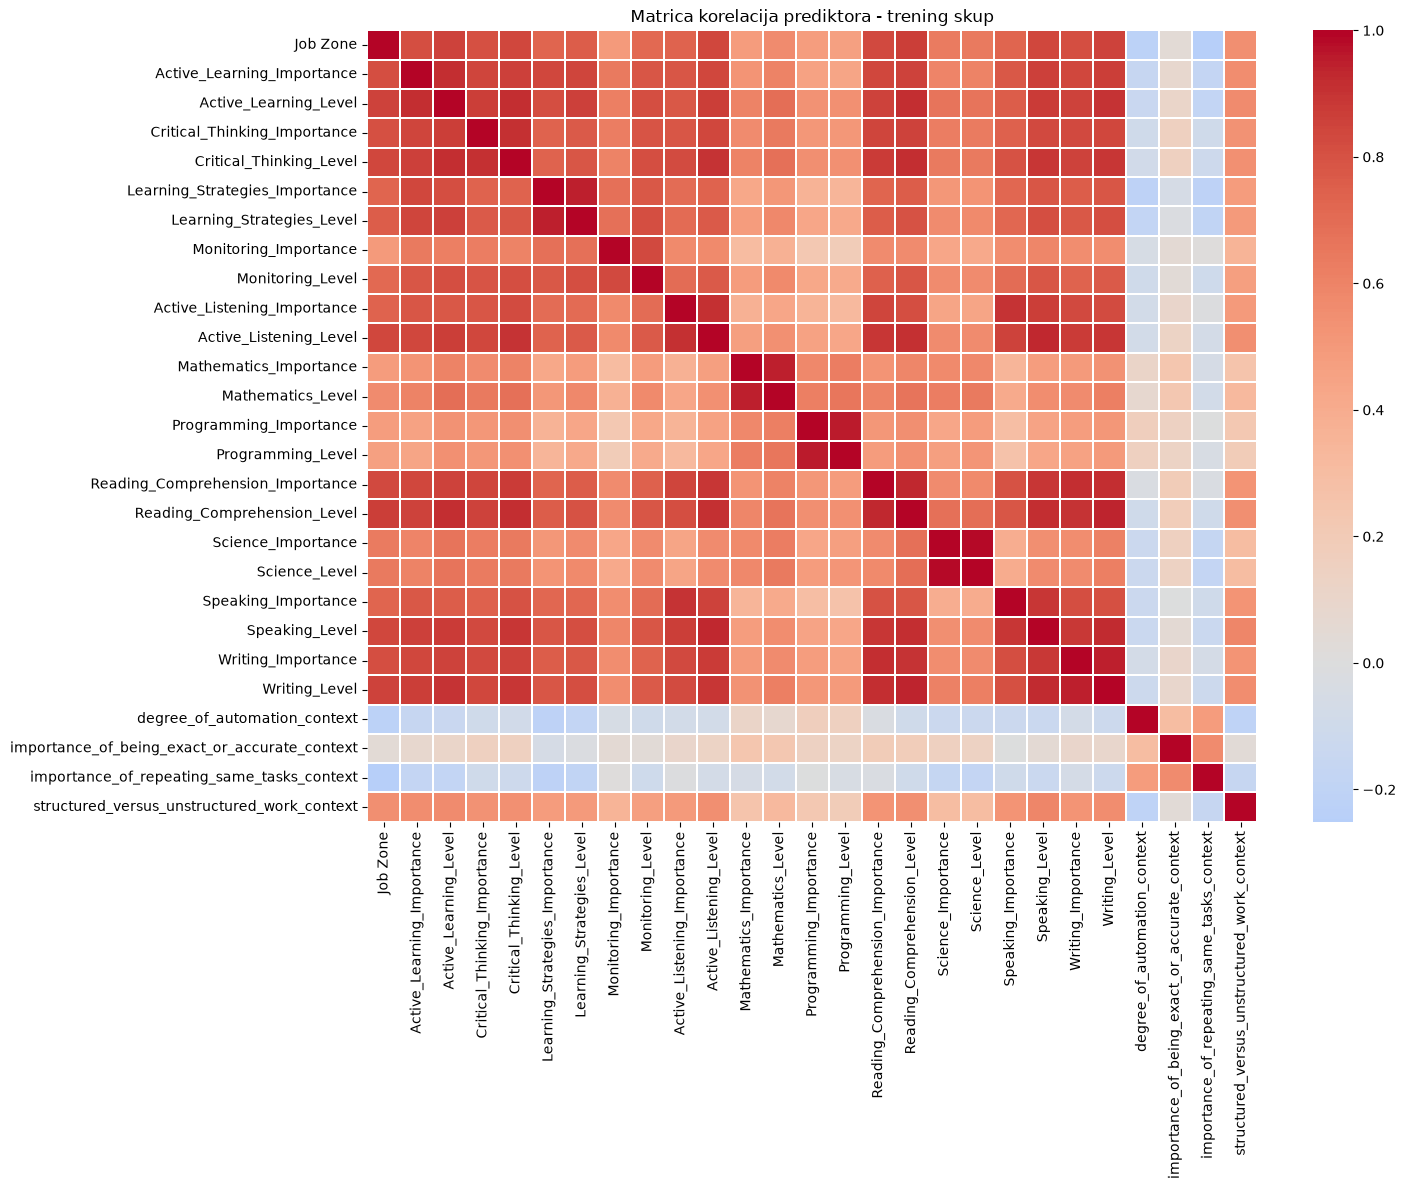

In [41]:
corr_train = X_train.corr()

plt.figure(figsize=(15, 12))

sns.heatmap(
    corr_train,
    cmap='coolwarm',
    center=0,
    linewidths=0.1
)

plt.title('Matrica korelacija prediktora - trening skup')
plt.tight_layout()

plt.savefig(
    'slike_redukcija/01_korelaciona_matrica_trening.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [42]:
CORR_THRESHOLD = 0.90

corr_abs = X_train.corr().abs()

upper_triangle = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    'feature_1',
    'feature_2',
    'abs_correlation'
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs['abs_correlation'] > CORR_THRESHOLD
    ]
    .sort_values(
        'abs_correlation',
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"Broj parova prediktora sa |r| > {CORR_THRESHOLD}:",
    len(high_corr_pairs)
)

display(high_corr_pairs)

Broj parova prediktora sa |r| > 0.9: 22


,feature_1,feature_2,abs_correlation
0,Science_Importance,Science_Level,0.981857
1,Programming_Importance,Programming_Level,0.957619
2,Learning_Strategies_Importance,Learning_Strategies_Level,0.949198
3,Writing_Importance,Writing_Level,0.945339
4,Mathematics_Importance,Mathematics_Level,0.944249
5,Reading_Comprehension_Level,Writing_Level,0.939432
6,Reading_Comprehension_Importance,Reading_Comprehension_Level,0.929067
7,Active_Listening_Level,Speaking_Level,0.928980
8,Speaking_Level,Writing_Level,0.922570
9,Reading_Comprehension_Importance,Writing_Level,0.920744


In [43]:
target_corr_train = (
    X_train
    .corrwith(y_train)
    .abs()
    .sort_values(ascending=False)
)

print("Apsolutna korelacija prediktora sa ciljem - trening skup:")
display(target_corr_train)

Apsolutna korelacija prediktora sa ciljem - trening skup:


Reading_Comprehension_Importance                 0.741299
Writing_Importance                               0.734113
Writing_Level                                    0.722752
Speaking_Level                                   0.698082
Reading_Comprehension_Level                      0.689176
Active_Listening_Level                           0.688942
Active_Listening_Importance                      0.680119
Speaking_Importance                              0.665751
Critical_Thinking_Level                          0.661186
Active_Learning_Level                            0.619092
Job Zone                                         0.606896
Critical_Thinking_Importance                     0.585867
Active_Learning_Importance                       0.581884
Programming_Importance                           0.542870
Programming_Level                                0.526091
Learning_Strategies_Level                        0.496084
Learning_Strategies_Importance                   0.480312
Mathematics_Le

In [44]:
# ==========================================================
# ITERATIVNA REDUKCIJA VISOKO KORELISANIH PREDIKTORA
# ==========================================================

CORR_THRESHOLD = 0.90

# Korelacija prediktora sa ciljnom promenljivom
# računa se ISKLJUČIVO na trening skupu
target_corr_train = (
    X_train
    .corrwith(y_train)
    .abs()
)

# Na početku su svi prediktori dostupni
remaining_features = list(X_train.columns)

reduction_steps = []

while True:
    
    # Međusobne korelacije samo trenutno preostalih prediktora
    current_corr = (
        X_train[remaining_features]
        .corr()
        .abs()
    )
    
    # Samo gornji trougao matrice
    upper = current_corr.where(
        np.triu(
            np.ones(current_corr.shape),
            k=1
        ).astype(bool)
    )
    
    correlations = upper.stack()
    
    # Ako nema više parova, završavamo
    if correlations.empty:
        break
    
    max_corr = correlations.max()
    
    # Ako najveća korelacija više nije preko praga
    if max_corr <= CORR_THRESHOLD:
        break
    
    # Najviše korelisan par
    feature_1, feature_2 = correlations.idxmax()
    
    corr_target_1 = target_corr_train[feature_1]
    corr_target_2 = target_corr_train[feature_2]
    
    # Zadržavamo onaj koji je jače povezan sa ciljem
    if corr_target_1 >= corr_target_2:
        feature_keep = feature_1
        feature_drop = feature_2
    else:
        feature_keep = feature_2
        feature_drop = feature_1
    
    reduction_steps.append({
        'feature_1': feature_1,
        'feature_2': feature_2,
        'correlation_between_features': max_corr,
        'corr_target_feature_1': corr_target_1,
        'corr_target_feature_2': corr_target_2,
        'kept_feature': feature_keep,
        'removed_feature': feature_drop
    })
    
    # Uklanjamo samo jednu promenljivu
    remaining_features.remove(feature_drop)


reduction_steps_df = pd.DataFrame(reduction_steps)

features_to_drop = [
    feature
    for feature in X_train.columns
    if feature not in remaining_features
]


print("Koraci redukcije:")
display(reduction_steps_df)

print("\nPromenljive koje će biti uklonjene:")

for feature in features_to_drop:
    print("-", feature)

print(
    "\nBroj uklonjenih promenljivih:",
    len(features_to_drop)
)

print(
    "Broj preostalih prediktora:",
    len(remaining_features)
)

print("\nPreostali prediktori:")

for feature in remaining_features:
    print("-", feature)

Koraci redukcije:


,feature_1,feature_2,correlation_between_features,corr_target_feature_1,corr_target_feature_2,kept_feature,removed_feature
0,Science_Importance,Science_Level,0.981857,0.265365,0.284065,Science_Level,Science_Importance
1,Programming_Importance,Programming_Level,0.957619,0.542870,0.526091,Programming_Importance,Programming_Level
2,Learning_Strategies_Importance,Learning_Strategies_Level,0.949198,0.480312,0.496084,Learning_Strategies_Level,Learning_Strategies_Importance
3,Writing_Importance,Writing_Level,0.945339,0.734113,0.722752,Writing_Importance,Writing_Level
4,Mathematics_Importance,Mathematics_Level,0.944249,0.447090,0.479811,Mathematics_Level,Mathematics_Importance
5,Reading_Comprehension_Importance,Reading_Comprehension_Level,0.929067,0.741299,0.689176,Reading_Comprehension_Importance,Reading_Comprehension_Level
6,Active_Listening_Level,Speaking_Level,0.928980,0.688942,0.698082,Speaking_Level,Active_Listening_Level
7,Active_Learning_Importance,Active_Learning_Level,0.920525,0.581884,0.619092,Active_Learning_Level,Active_Learning_Importance
8,Reading_Comprehension_Importance,Writing_Importance,0.920462,0.741299,0.734113,Reading_Comprehension_Importance,Writing_Importance
9,Active_Learning_Level,Critical_Thinking_Level,0.913968,0.619092,0.661186,Critical_Thinking_Level,Active_Learning_Level



Promenljive koje će biti uklonjene:
- Active_Learning_Importance
- Active_Learning_Level
- Critical_Thinking_Importance
- Learning_Strategies_Importance
- Active_Listening_Level
- Mathematics_Importance
- Programming_Level
- Reading_Comprehension_Level
- Science_Importance
- Speaking_Importance
- Writing_Importance
- Writing_Level

Broj uklonjenih promenljivih: 12
Broj preostalih prediktora: 15

Preostali prediktori:
- Job Zone
- Critical_Thinking_Level
- Learning_Strategies_Level
- Monitoring_Importance
- Monitoring_Level
- Active_Listening_Importance
- Mathematics_Level
- Programming_Importance
- Reading_Comprehension_Importance
- Science_Level
- Speaking_Level
- degree_of_automation_context
- importance_of_being_exact_or_accurate_context
- importance_of_repeating_same_tasks_context
- structured_versus_unstructured_work_context


In [45]:
X_train_reduced = X_train[remaining_features].copy()
X_test_reduced = X_test[remaining_features].copy()

reduced_corr = X_train_reduced.corr().abs()

upper_reduced = reduced_corr.where(
    np.triu(
        np.ones(reduced_corr.shape),
        k=1
    ).astype(bool)
)

remaining_pairs = (
    upper_reduced
    .stack()
    .sort_values(ascending=False)
)

remaining_pairs = remaining_pairs[
    remaining_pairs > CORR_THRESHOLD
]

print(
    f"Broj preostalih parova sa |r| > {CORR_THRESHOLD}:",
    len(remaining_pairs)
)

display(remaining_pairs)

Broj preostalih parova sa |r| > 0.9: 0


Series([], dtype: float64)

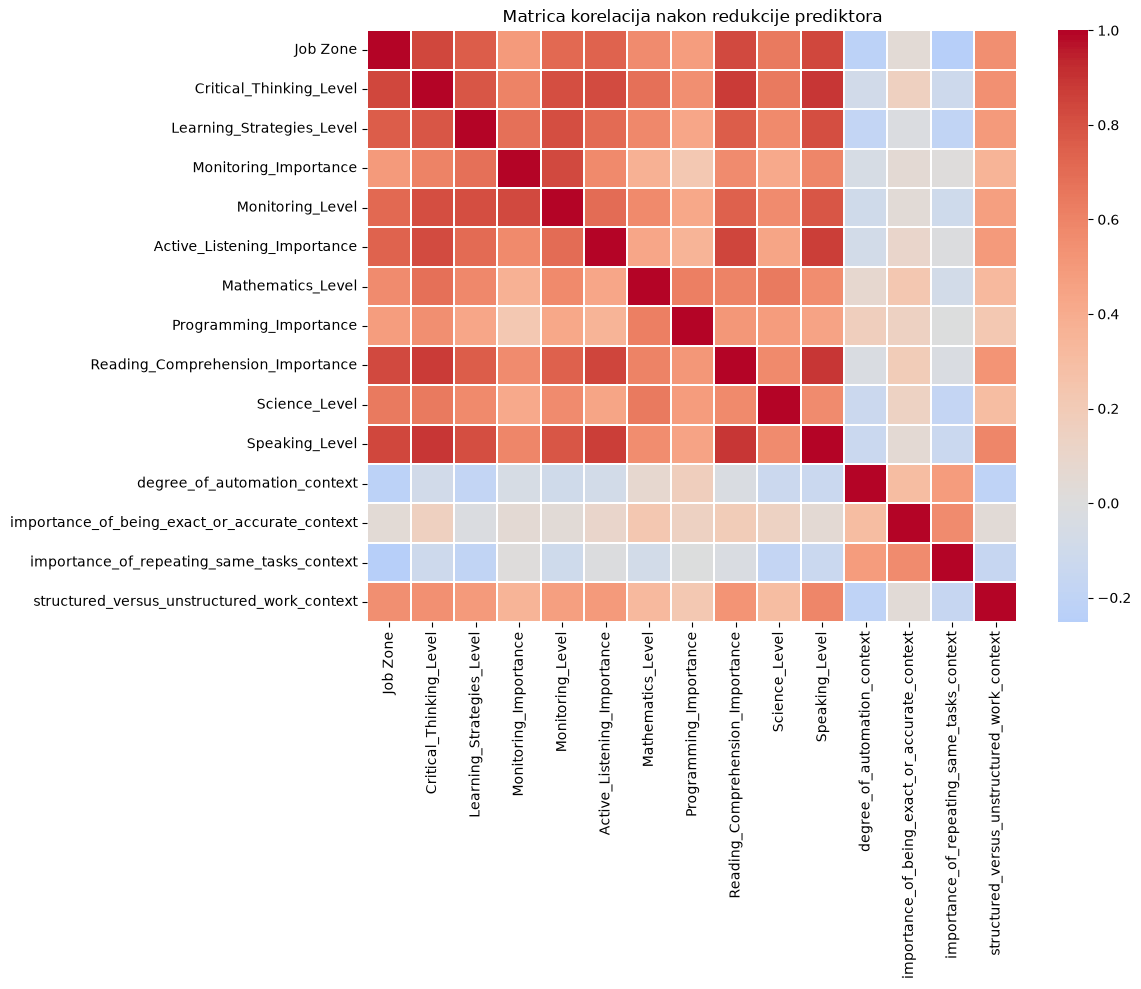

In [46]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    X_train_reduced.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.1
)

plt.title('Matrica korelacija nakon redukcije prediktora')
plt.tight_layout()

plt.savefig(
    'slike_redukcija/02_korelaciona_matrica_redukovani_skup.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [47]:
ridge_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])

In [48]:
rf_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [49]:
xgb_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=5,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

In [50]:
cat_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', CatBoostRegressor(
        iterations=500,
        depth=8,
        learning_rate=0.03,
        l2_leaf_reg=3,
        subsample=0.8,
        random_state=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=1
    ))
])

In [51]:
mlp_reduced = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        alpha=1.0,
        learning_rate_init=0.001,
        solver='adam',
        early_stopping=True,
        validation_fraction=0.20,
        n_iter_no_change=20,
        max_iter=2000,
        random_state=42
    ))
])

In [52]:
reduced_models = {
    'Ridge': ridge_reduced,
    'Random Forest': rf_reduced,
    'XGBoost': xgb_reduced,
    'CatBoost': cat_reduced,
    'Neural Network': mlp_reduced
}

In [53]:
reduced_results = {}

for name, model in reduced_models.items():
    
    print("=" * 50)
    print("Treniranje:", name)
    
    model.fit(
        X_train_reduced,
        y_train
    )
    
    y_pred = model.predict(
        X_test_reduced
    )
    
    mae = mean_absolute_error(
        y_test,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_test,
        y_pred
    )
    
    spearman, _ = spearmanr(
        y_test,
        y_pred
    )
    
    reduced_results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Spearman': spearman
    }
    
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    print(f"R2:       {r2:.4f}")
    print(f"Spearman: {spearman:.4f}")

Treniranje: Ridge
MAE:      0.0976
RMSE:     0.1238
R2:       0.6382
Spearman: 0.8147
Treniranje: Random Forest
MAE:      0.0883
RMSE:     0.1178
R2:       0.6728
Spearman: 0.8279
Treniranje: XGBoost
MAE:      0.0837
RMSE:     0.1127
R2:       0.7001
Spearman: 0.8469
Treniranje: CatBoost
MAE:      0.0839
RMSE:     0.1113
R2:       0.7079
Spearman: 0.8491
Treniranje: Neural Network
MAE:      0.0880
RMSE:     0.1168
R2:       0.6780
Spearman: 0.8343


In [54]:
reduced_results_df = (
    pd.DataFrame(reduced_results)
    .T
    .round(4)
    .sort_values('MAE', ascending=True)
)

print("Rezultati na test skupu sa 15 prediktora:")
display(reduced_results_df)

Rezultati na test skupu sa 15 prediktora:


,MAE,RMSE,R2,Spearman
XGBoost,0.0837,0.1127,0.7001,0.8469
CatBoost,0.0839,0.1113,0.7079,0.8491
Neural Network,0.0880,0.1168,0.6780,0.8343
Random Forest,0.0883,0.1178,0.6728,0.8279
Ridge,0.0976,0.1238,0.6382,0.8147


In [55]:
original_results = pd.DataFrame(
    {
        'MAE': {
            'Neural Network': 0.0826,
            'CatBoost': 0.0832,
            'XGBoost': 0.0842,
            'Random Forest': 0.0851,
            'Ridge': 0.0905
        },
        
        'RMSE': {
            'Neural Network': 0.1078,
            'CatBoost': 0.1088,
            'XGBoost': 0.1126,
            'Random Forest': 0.1120,
            'Ridge': 0.1159
        },
        
        'R2': {
            'Neural Network': 0.7256,
            'CatBoost': 0.7207,
            'XGBoost': 0.7007,
            'Random Forest': 0.7043,
            'Ridge': 0.6832
        },
        
        'Spearman': {
            'Neural Network': 0.8561,
            'CatBoost': 0.8518,
            'XGBoost': 0.8473,
            'Random Forest': 0.8497,
            'Ridge': 0.8376
        }
    }
)

display(original_results)

,MAE,RMSE,R2,Spearman
Neural Network,0.0826,0.1078,0.7256,0.8561
CatBoost,0.0832,0.1088,0.7207,0.8518
XGBoost,0.0842,0.1126,0.7007,0.8473
Random Forest,0.0851,0.1120,0.7043,0.8497
Ridge,0.0905,0.1159,0.6832,0.8376


In [56]:
comparison_short = pd.DataFrame(
    index=original_results.index
)

comparison_short['MAE - 27 prediktora'] = (
    original_results['MAE']
)

comparison_short['MAE - 15 prediktora'] = (
    reduced_results_df
    .reindex(original_results.index)['MAE']
)

comparison_short['R2 - 27 prediktora'] = (
    original_results['R2']
)

comparison_short['R2 - 15 prediktora'] = (
    reduced_results_df
    .reindex(original_results.index)['R2']
)

comparison_short['Razlika MAE'] = (
    comparison_short['MAE - 15 prediktora']
    - comparison_short['MAE - 27 prediktora']
)

comparison_short['Razlika R2'] = (
    comparison_short['R2 - 15 prediktora']
    - comparison_short['R2 - 27 prediktora']
)

comparison_short = comparison_short.round(4)

display(comparison_short)

,MAE - 27 prediktora,MAE - 15 prediktora,R2 - 27 prediktora,R2 - 15 prediktora,Razlika MAE,Razlika R2
Neural Network,0.0826,0.0880,0.7256,0.6780,0.0054,-0.0476
CatBoost,0.0832,0.0839,0.7207,0.7079,0.0007,-0.0128
XGBoost,0.0842,0.0837,0.7007,0.7001,-0.0005,-0.0006
Random Forest,0.0851,0.0883,0.7043,0.6728,0.0032,-0.0315
Ridge,0.0905,0.0976,0.6832,0.6382,0.0071,-0.0450


In [57]:
comparison_full = pd.DataFrame(
    index=original_results.index
)

for metric in ['MAE', 'RMSE', 'R2', 'Spearman']:
    
    comparison_full[f'{metric}_27'] = (
        original_results[metric]
    )
    
    comparison_full[f'{metric}_15'] = (
        reduced_results_df
        .reindex(original_results.index)[metric]
    )
    
    comparison_full[f'delta_{metric}'] = (
        comparison_full[f'{metric}_15']
        - comparison_full[f'{metric}_27']
    )

comparison_full = comparison_full.round(4)

display(comparison_full)

,MAE_27,MAE_15,delta_MAE,RMSE_27,RMSE_15,delta_RMSE,R2_27,R2_15,delta_R2,Spearman_27,Spearman_15,delta_Spearman
Neural Network,0.0826,0.0880,0.0054,0.1078,0.1168,0.0090,0.7256,0.6780,-0.0476,0.8561,0.8343,-0.0218
CatBoost,0.0832,0.0839,0.0007,0.1088,0.1113,0.0025,0.7207,0.7079,-0.0128,0.8518,0.8491,-0.0027
XGBoost,0.0842,0.0837,-0.0005,0.1126,0.1127,0.0001,0.7007,0.7001,-0.0006,0.8473,0.8469,-0.0004
Random Forest,0.0851,0.0883,0.0032,0.1120,0.1178,0.0058,0.7043,0.6728,-0.0315,0.8497,0.8279,-0.0218
Ridge,0.0905,0.0976,0.0071,0.1159,0.1238,0.0079,0.6832,0.6382,-0.0450,0.8376,0.8147,-0.0229


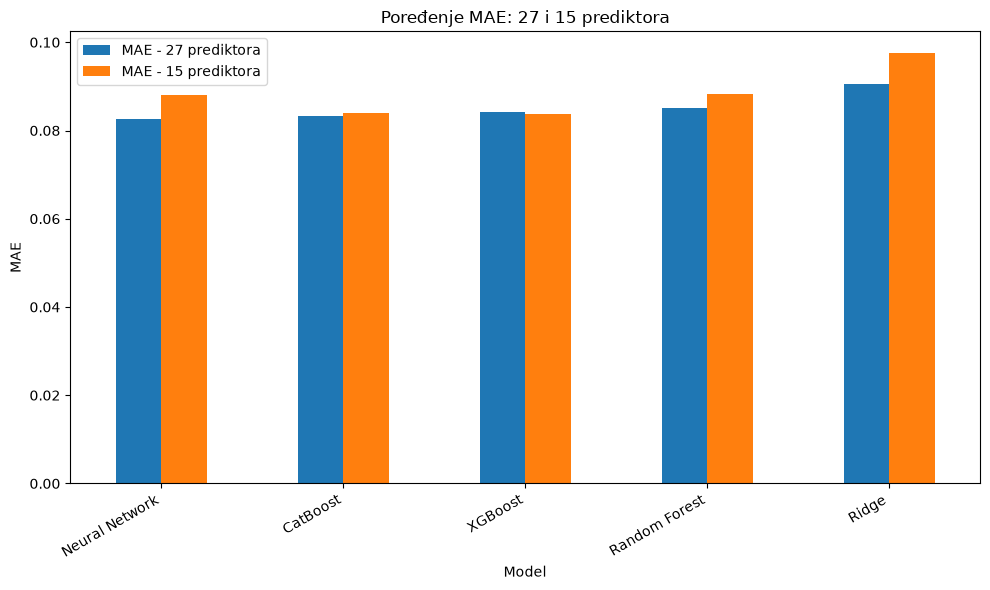

In [58]:
mae_comparison = comparison_short[
    [
        'MAE - 27 prediktora',
        'MAE - 15 prediktora'
    ]
]

mae_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.ylabel('MAE')
plt.xlabel('Model')
plt.title('Poređenje MAE: 27 i 15 prediktora')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()

plt.savefig(
    'slike_redukcija/03_poredjenje_MAE.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

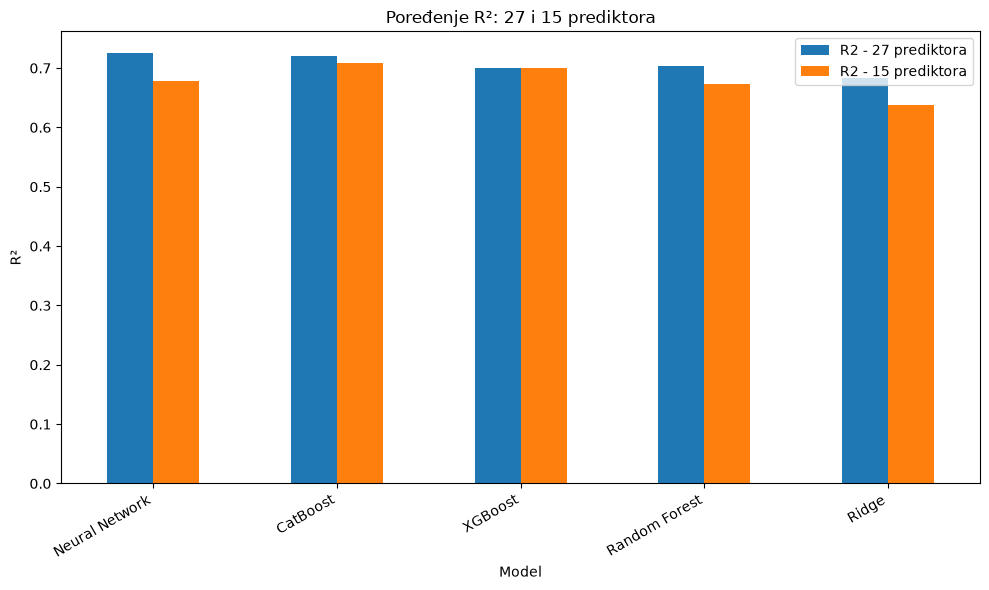

In [59]:
r2_comparison = comparison_short[
    [
        'R2 - 27 prediktora',
        'R2 - 15 prediktora'
    ]
]

r2_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.ylabel('R²')
plt.xlabel('Model')
plt.title('Poređenje R²: 27 i 15 prediktora')

plt.xticks(
    rotation=30,
    ha='right'
)

plt.tight_layout()

plt.savefig(
    'slike_redukcija/04_poredjenje_R2.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [60]:
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

reduced_cv_results = {}

for name, model in reduced_models.items():
    
    print("5-fold CV:", name)
    
    scores = cross_validate(
        model,
        X_train_reduced,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    reduced_cv_results[name] = {
        'MAE_mean': -scores['test_MAE'].mean(),
        'MAE_std': scores['test_MAE'].std(),
        
        'RMSE_mean': -scores['test_RMSE'].mean(),
        'RMSE_std': scores['test_RMSE'].std(),
        
        'R2_mean': scores['test_R2'].mean(),
        'R2_std': scores['test_R2'].std()
    }


reduced_cv_df = (
    pd.DataFrame(reduced_cv_results)
    .T
    .round(4)
    .sort_values('R2_mean', ascending=False)
)

display(reduced_cv_df)

5-fold CV: Ridge
5-fold CV: Random Forest
5-fold CV: XGBoost
5-fold CV: CatBoost
5-fold CV: Neural Network


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
XGBoost,0.0827,0.0064,0.1080,0.0098,0.7312,0.0378
CatBoost,0.0831,0.0075,0.1090,0.0105,0.7261,0.0415
Random Forest,0.0843,0.0073,0.1098,0.0107,0.7216,0.0455
Neural Network,0.0858,0.0065,0.1122,0.0094,0.7087,0.0421
Ridge,0.0910,0.0063,0.1153,0.0097,0.6939,0.0362


In [61]:
original_cv = pd.DataFrame(
    {
        'MAE_mean': {
            'CatBoost': 0.0780,
            'XGBoost': 0.0792,
            'Neural Network': 0.0807,
            'Random Forest': 0.0792,
            'Ridge': 0.0878
        },
        
        'R2_mean': {
            'CatBoost': 0.7587,
            'XGBoost': 0.7532,
            'Neural Network': 0.7509,
            'Random Forest': 0.7501,
            'Ridge': 0.7153
        }
    }
)

display(original_cv)

,MAE_mean,R2_mean
CatBoost,0.0780,0.7587
XGBoost,0.0792,0.7532
Neural Network,0.0807,0.7509
Random Forest,0.0792,0.7501
Ridge,0.0878,0.7153


In [62]:
cv_comparison = pd.DataFrame(
    index=original_cv.index
)

cv_comparison['MAE_27'] = (
    original_cv['MAE_mean']
)

cv_comparison['MAE_15'] = (
    reduced_cv_df
    .reindex(original_cv.index)['MAE_mean']
)

cv_comparison['delta_MAE'] = (
    cv_comparison['MAE_15']
    - cv_comparison['MAE_27']
)


cv_comparison['R2_27'] = (
    original_cv['R2_mean']
)

cv_comparison['R2_15'] = (
    reduced_cv_df
    .reindex(original_cv.index)['R2_mean']
)

cv_comparison['delta_R2'] = (
    cv_comparison['R2_15']
    - cv_comparison['R2_27']
)

cv_comparison = cv_comparison.round(4)

display(cv_comparison)

,MAE_27,MAE_15,delta_MAE,R2_27,R2_15,delta_R2
CatBoost,0.0780,0.0831,0.0051,0.7587,0.7261,-0.0326
XGBoost,0.0792,0.0827,0.0035,0.7532,0.7312,-0.0220
Neural Network,0.0807,0.0858,0.0051,0.7509,0.7087,-0.0422
Random Forest,0.0792,0.0843,0.0051,0.7501,0.7216,-0.0285
Ridge,0.0878,0.0910,0.0032,0.7153,0.6939,-0.0214


In [63]:
print("=" * 70)
print("KONTROLNI EKSPERIMENT REDUKCIJE PREDIKTORA")
print("=" * 70)

print("\nOriginalni broj prediktora:", X_train.shape[1])
print("Broj uklonjenih prediktora:", len(features_to_drop))
print("Broj preostalih prediktora:", X_train_reduced.shape[1])

print("\nUklonjeni prediktori:")

for feature in features_to_drop:
    print("-", feature)

print("\nTEST SKUP:")
display(comparison_short)

print("\n5-FOLD CROSS-VALIDATION:")
display(cv_comparison)

KONTROLNI EKSPERIMENT REDUKCIJE PREDIKTORA

Originalni broj prediktora: 27
Broj uklonjenih prediktora: 12
Broj preostalih prediktora: 15

Uklonjeni prediktori:
- Active_Learning_Importance
- Active_Learning_Level
- Critical_Thinking_Importance
- Learning_Strategies_Importance
- Active_Listening_Level
- Mathematics_Importance
- Programming_Level
- Reading_Comprehension_Level
- Science_Importance
- Speaking_Importance
- Writing_Importance
- Writing_Level

TEST SKUP:


,MAE - 27 prediktora,MAE - 15 prediktora,R2 - 27 prediktora,R2 - 15 prediktora,Razlika MAE,Razlika R2
Neural Network,0.0826,0.0880,0.7256,0.6780,0.0054,-0.0476
CatBoost,0.0832,0.0839,0.7207,0.7079,0.0007,-0.0128
XGBoost,0.0842,0.0837,0.7007,0.7001,-0.0005,-0.0006
Random Forest,0.0851,0.0883,0.7043,0.6728,0.0032,-0.0315
Ridge,0.0905,0.0976,0.6832,0.6382,0.0071,-0.0450



5-FOLD CROSS-VALIDATION:


,MAE_27,MAE_15,delta_MAE,R2_27,R2_15,delta_R2
CatBoost,0.0780,0.0831,0.0051,0.7587,0.7261,-0.0326
XGBoost,0.0792,0.0827,0.0035,0.7532,0.7312,-0.0220
Neural Network,0.0807,0.0858,0.0051,0.7509,0.7087,-0.0422
Random Forest,0.0792,0.0843,0.0051,0.7501,0.7216,-0.0285
Ridge,0.0878,0.0910,0.0032,0.7153,0.6939,-0.0214
